# Install Libraries

In [1]:
!pip install -q tensorflow tensorflow-hub

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import os

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


# Download dataset

In [3]:
!pip install -q kaggle
!kaggle datasets download -d mahmoudreda55/satellite-image-classification

Dataset URL: https://www.kaggle.com/datasets/mahmoudreda55/satellite-image-classification
License(s): copyright-authors
100% 21.8M/21.8M [00:00<00:00, 136MB/s]



# Unzip the dataset

In [15]:
import zipfile

with zipfile.ZipFile('/content/satellite-image-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/satellite_dataset')

print("Done. Contents:")
!ls /content/satellite_dataset

Done. Contents:
data


In [16]:
DATA_DIR = '/content/satellite_dataset/data'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation

In [17]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)


val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 5631 files belonging to 4 classes.
Using 4505 files for training.
Found 5631 files belonging to 4 classes.
Using 1126 files for validation.
Classes: ['cloudy', 'desert', 'green_area', 'water']


#Build model (frozen base)

In [18]:
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,559 (16.71 MB)

 Trainable params: 329,476 (1.26 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

# Train the head

In [19]:
early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.9765 - loss: 0.0740 - val_accuracy: 0.9964 - val_loss: 0.0170 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.9889 - loss: 0.0351 - val_accuracy: 1.0000 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9945 - val_loss: 0.0114 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.9911 - loss: 0.0261 - val_accuracy: 0.9964 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9909 - loss: 0.0267 - val_accuracy: 0.9982 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy: 0.9913 - loss: 0.0252 - val_accuracy: 1.0000 - val_loss: 0.0020 - learning_rate: 0.0010
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.9918 - 

# Fine Tuning

In [20]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.8)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = callbacks.EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop_ft, reduce_lr]
)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 126ms/step - accuracy: 0.8850 - loss: 0.3530 - val_accuracy: 0.9855 - val_loss: 0.0378 - learning_rate: 1.0000e-05
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.9567 - loss: 0.1406 - val_accuracy: 0.9909 - val_loss: 0.0353 - learning_rate: 1.0000e-05
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.9676 - loss: 0.1073 - val_accuracy: 0.9891 - val_loss: 0.0303 - learning_rate: 1.0000e-05
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.9778 - loss: 0.0753 - val_accuracy: 0.9891 - val_loss: 0.0307 - learning_rate: 5.0000e-06
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.9738 - loss: 0.0805 - val_accuracy: 0.9891 - val_loss: 0.0257 - learning_rate: 5.0000e-06
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 107ms/step - accuracy: 0.9796 - loss: 0.0703 - val_accuracy: 0.9891 - val_loss: 0.0227 - learning_rate: 5.0000e-06
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 10

# Evaluate on test set

In [21]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc*100:.2f}%")

train_acc = history2.history['accuracy'][-1]
print(f"Final training accuracy: {train_acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.9861 - loss: 0.0485
Test accuracy: 98.61%
Final training accuracy: 98.22%


# Plotting curves

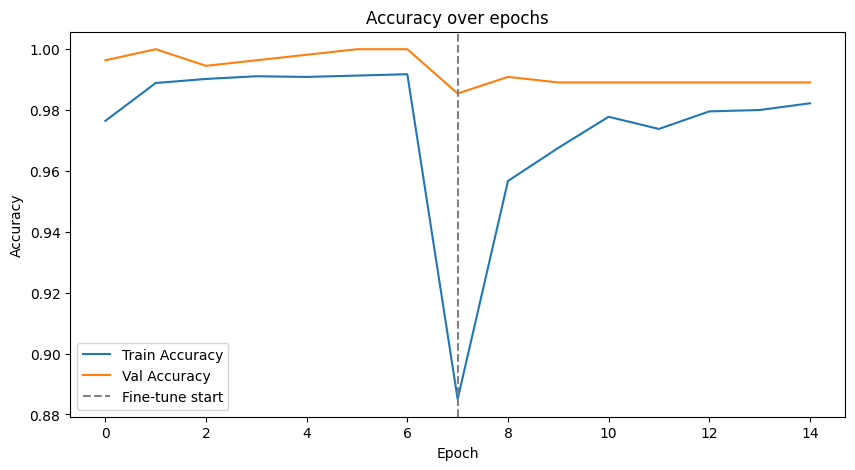

In [22]:
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(10,5))
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(len(history1.history['accuracy']), color='gray', linestyle='--', label='Fine-tune start')
plt.legend()
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [25]:
import numpy as np

y_true = []
y_pred_probs = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

y_true_classes = np.argmax(y_true, axis=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("Total test samples:", len(y_true_classes))

Total test samples: 576


# ROC Curve

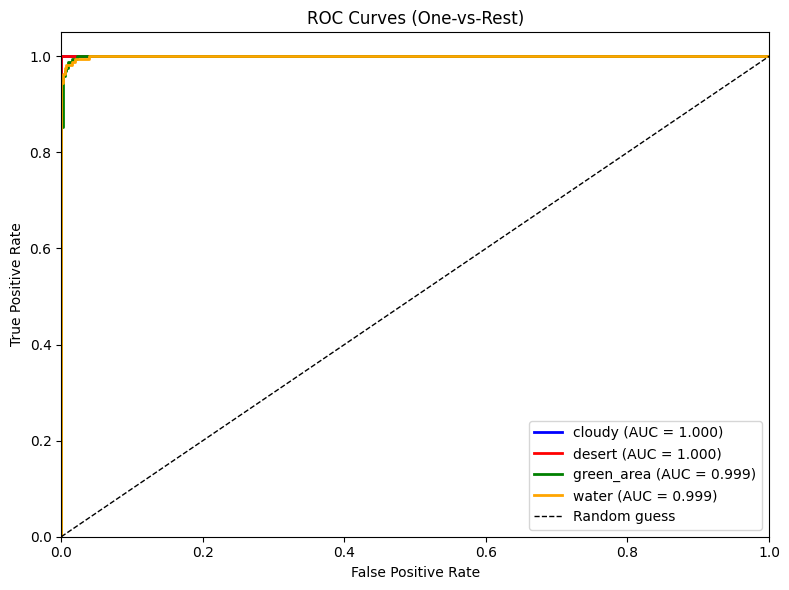

In [26]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle

num_classes = len(class_names)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'brown'])

for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

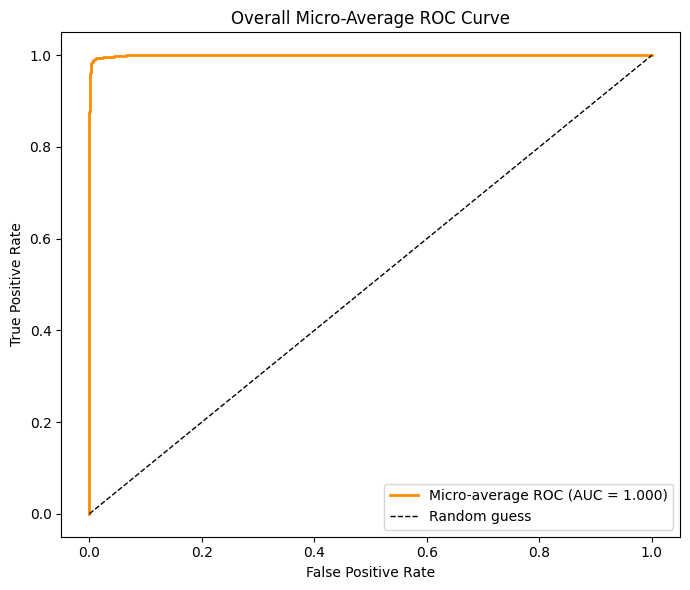

In [27]:
from sklearn.metrics import roc_curve, auc

fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_pred_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.figure(figsize=(7, 6))
plt.plot(fpr_micro, tpr_micro, color='darkorange', lw=2,
         label=f'Micro-average ROC (AUC = {roc_auc_micro:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall Micro-Average ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Confusion Matrix

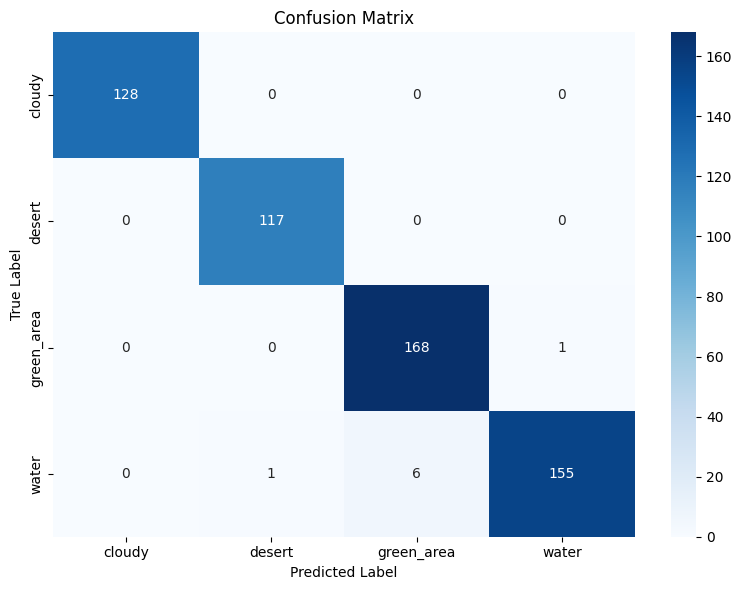


Classification Report:

              precision    recall  f1-score   support

      cloudy       1.00      1.00      1.00       128
      desert       0.99      1.00      1.00       117
  green_area       0.97      0.99      0.98       169
       water       0.99      0.96      0.97       162

    accuracy                           0.99       576
   macro avg       0.99      0.99      0.99       576
weighted avg       0.99      0.99      0.99       576



In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

# Model Prediction

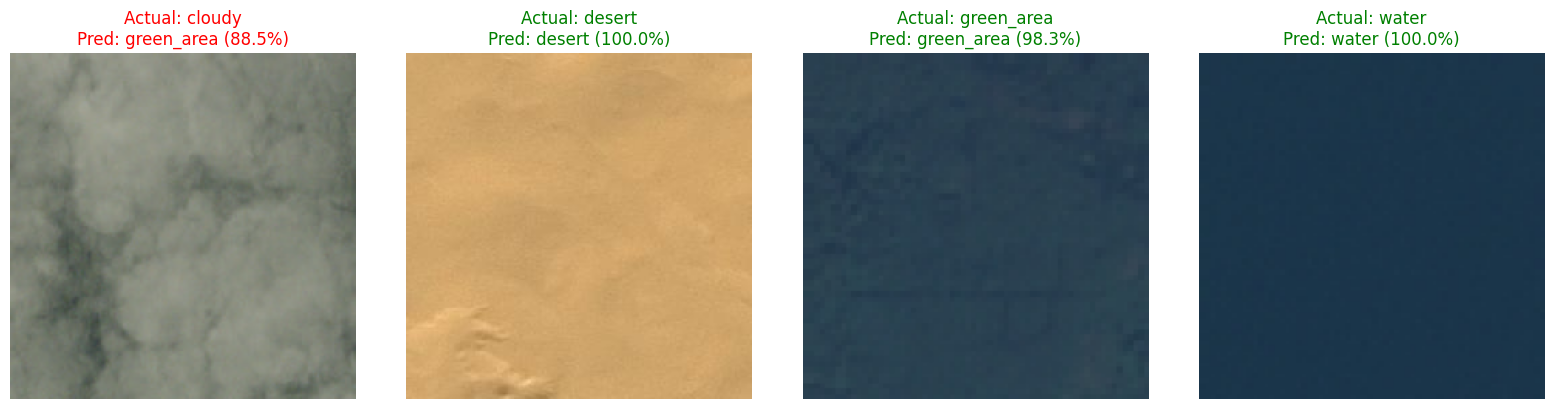

In [30]:
import os
import random
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

data_root = '/content/satellite_dataset/data'

plt.figure(figsize=(16, 4))
for i, cls in enumerate(class_names):
    class_dir = os.path.join(data_root, cls)
    random_img = random.choice(os.listdir(class_dir))
    img_path = os.path.join(class_dir, random_img)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array, verbose=0)
    pred_class = np.argmax(predictions[0])
    confidence = predictions[0][pred_class] * 100

    plt.subplot(1, len(class_names), i + 1)
    plt.imshow(img)
    color = "green" if class_names[pred_class] == cls else "red"
    plt.title(f"Actual: {cls}\nPred: {class_names[pred_class]} ({confidence:.1f}%)", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Single image prediction

In [36]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_single_image(
    image_path,
    trained_model=model
):

    image = load_img(
        image_path,
        target_size=IMG_SIZE
    )

    image_array = img_to_array(image)
    image_array = np.expand_dims(
        image_array,
        axis=0
    )
    image_array = preprocess_input(image_array)

    probabilities = trained_model.predict(
        image_array,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        probabilities
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = probabilities[
        predicted_index
    ]

    print("Prediction:", predicted_class)
    print(
        f"Confidence: {confidence * 100:.2f}%"
    )

    print("\nClass probabilities:")

    for i, class_name in enumerate(class_names):
        print(
            f"{class_name}: "
            f"{probabilities[i] * 100:.2f}%"
        )

    plt.figure(figsize=(6, 6))
    plt.imshow(Image.open(image_path).convert("RGB"))
    plt.title(
        f"Prediction: {predicted_class}\n"
        f"Confidence: {confidence * 100:.2f}%"
    )
    plt.axis("off")
    plt.show()

    return predicted_class, confidence, probabilities


Prediction: green_area
Confidence: 98.77%

Class probabilities:
cloudy: 0.00%
desert: 1.23%
green_area: 98.77%
water: 0.00%


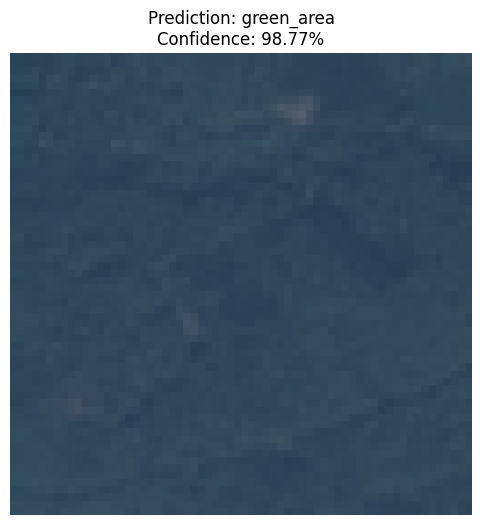

('green_area',
 np.float32(0.98766613),
 array([1.9883999e-05, 1.2312998e-02, 9.8766613e-01, 9.7613133e-07],
       dtype=float32))

In [37]:
TEST_IMAGE = "/content/satellite_dataset/data/green_area/Forest_1470.jpg"
predict_single_image(TEST_IMAGE)

Prediction: desert
Confidence: 100.00%

Class probabilities:
cloudy: 0.00%
desert: 100.00%
green_area: 0.00%
water: 0.00%


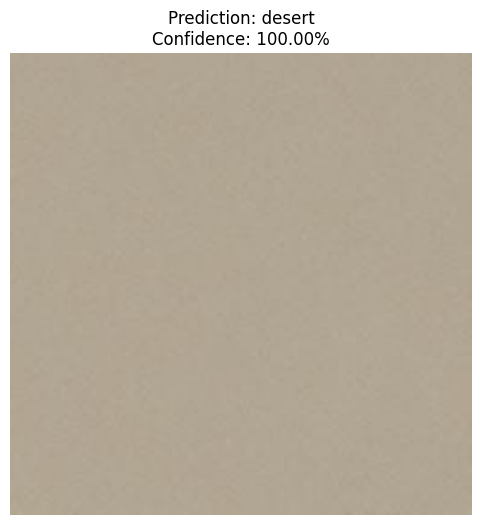

('desert',
 np.float32(0.99999714),
 array([9.0357452e-07, 9.9999714e-01, 7.6657290e-07, 1.1687816e-06],
       dtype=float32))

In [38]:
TEST_IMAGE = "/content/satellite_dataset/data/desert/desert(1006).jpg"
predict_single_image(TEST_IMAGE)

Prediction: water
Confidence: 99.58%

Class probabilities:
cloudy: 0.02%
desert: 0.38%
green_area: 0.02%
water: 99.58%


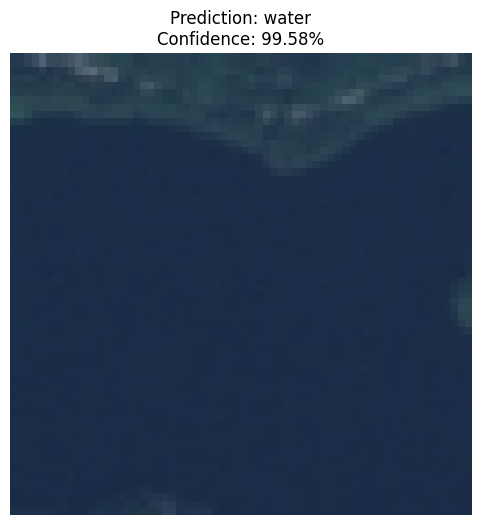

('water',
 np.float32(0.9958482),
 array([2.0468737e-04, 3.7814986e-03, 1.6560857e-04, 9.9584818e-01],
       dtype=float32))

In [48]:
TEST_IMAGE = "/content/satellite_dataset/data/water/SeaLake_1011.jpg"
predict_single_image(TEST_IMAGE)

# Save model

In [49]:
model.save('/content/satellite_efficientnetb0.keras')

from google.colab import files
files.download('/content/satellite_efficientnetb0.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>